In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import joblib
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully")

All libraries loaded successfully


In [3]:
df = pd.read_csv('../data/diamonds.csv')
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (53940, 11)

First 5 rows:


,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [4]:
print("Column types:", df.dtypes)
print("\nMissing values:", df.isnull().sum())
print("\nBasic Statistics:", df.describe())

Column types: Unnamed: 0      int64
carat         float64
cut               str
color             str
clarity           str
depth         float64
table         float64
price           int64
x             float64
y             float64
z             float64
dtype: object

Missing values: Unnamed: 0    0
carat         0
cut           0
color         0
clarity       0
depth         0
table         0
price         0
x             0
y             0
z             0
dtype: int64

Basic Statistics:          Unnamed: 0         carat         depth         table         price  \
count  53940.000000  53940.000000  53940.000000  53940.000000  53940.000000   
mean   26970.500000      0.797940     61.749405     57.457184   3932.799722   
std    15571.281097      0.474011      1.432621      2.234491   3989.439738   
min        1.000000      0.200000     43.000000     43.000000    326.000000   
25%    13485.750000      0.400000     61.000000     56.000000    950.000000   
50%    26970.500000      0.7000

In [5]:
print(df.columns.tolist())

df = df.drop(columns=['Unnamed: 0'])



['Unnamed: 0', 'carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y', 'z']


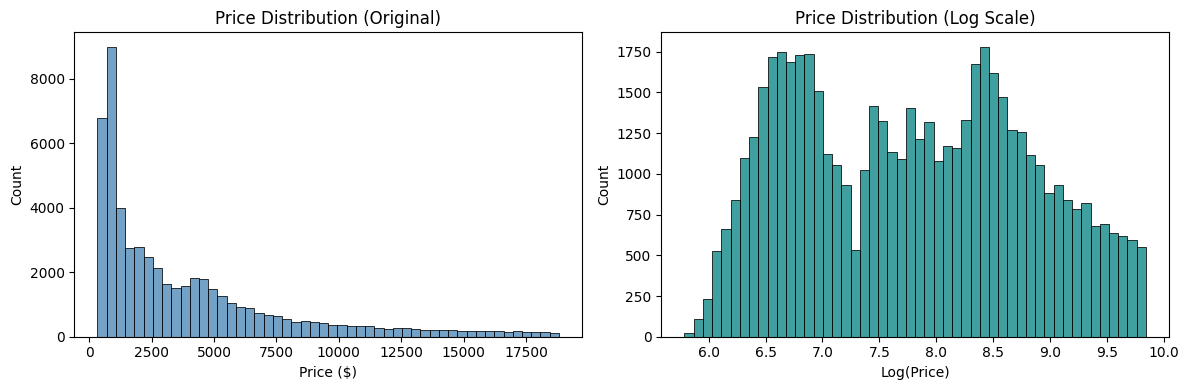

Chart done


In [6]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(df['price'], color='steelblue', bins=50)
plt.title('Price Distribution (Original)')
plt.xlabel('Price ($)')


plt.subplot(1,2,2)
sns.histplot(np.log(df['price']), color='teal', bins=50)
plt.title('Price Distribution (Log Scale)')
plt.xlabel('Log(Price)')

plt.tight_layout()
plt.show()

print("Chart done")

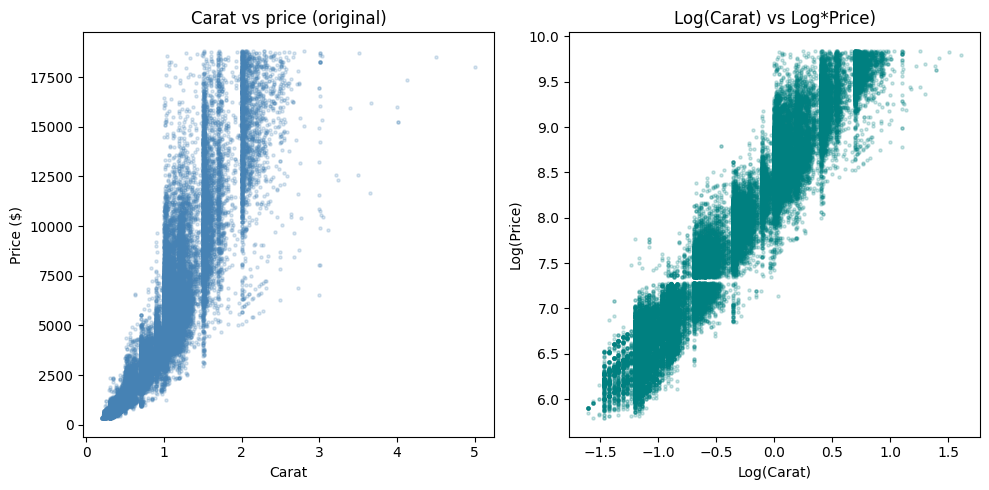

Scatter plots done


In [7]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.scatter(df['carat'], df['price'], alpha=0.2, color='steelblue',s=5)
plt.title('Carat vs price (original)')
plt.xlabel('Carat')
plt.ylabel('Price ($)')


plt.subplot(1,2,2)
plt.scatter(np.log(df['carat']), np.log(df['price']), alpha=0.2, color='teal', s=5)
plt.title('Log(Carat) vs Log*Price)')
plt.xlabel('Log(Carat)')
plt.ylabel('Log(Price)')

plt.tight_layout()
plt.show()

print("Scatter plots done")

In [8]:
df_clean = df.copy()

df_clean = df_clean[(df_clean['x']>0) & (df_clean['y']>0) & (df_clean['z']>0)]

cut_order = {'Fair':1, 'Good':2, 'Very Good':3, 'Premium':4, 'Ideal':5}
color_order ={'J':1, 'I':2, 'H':3, 'G':4, 'F':5, 'E':6, 'D':7}
clarity_order = {'I1':1, 'SI2':2, 'SI1':3, 'VS2':4, 'VS1':5, 'VVS2':6, 'VVS1':7, 'IF':8, 'FL':9}

df_clean['cut'] = df_clean['cut'].map(cut_order)
df_clean['color'] = df_clean['color'].map(color_order)
df_clean['clarity'] = df_clean['clarity'].map(clarity_order)

print("Data clean and encoded")
print(f"Rows before: {len(df)} -> Rows after: {len(df_clean)}")
print("\n Sample of encoded data:")
df_clean[['carat', 'cut', 'color', 'clarity', 'price']].head()


Data clean and encoded
Rows before: 53940 -> Rows after: 53920

 Sample of encoded data:


,carat,cut,color,clarity,price
0,0.23,5,6,2,326
1,0.21,4,6,3,326
2,0.23,2,6,5,327
3,0.29,4,2,4,334
4,0.31,2,1,2,335


In [9]:
X = df_clean[['carat', 'cut','color','clarity','depth','table','x','y','z']]
y = np.log(df_clean['price'])   # lof transform for better accuracy

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse =np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R2 score: {r2:.4f}")
print(f"RMSE (log scale): {rmse:.4f}")

rmse_dollars = np.sqrt(mean_squared_error(np.exp(y_test), np.exp(y_pred)))
print(f"RMSE (dollars): ${rmse_dollars:,.0f}")

R2 score: 0.9923
RMSE (log scale): 0.0890
RMSE (dollars): $525


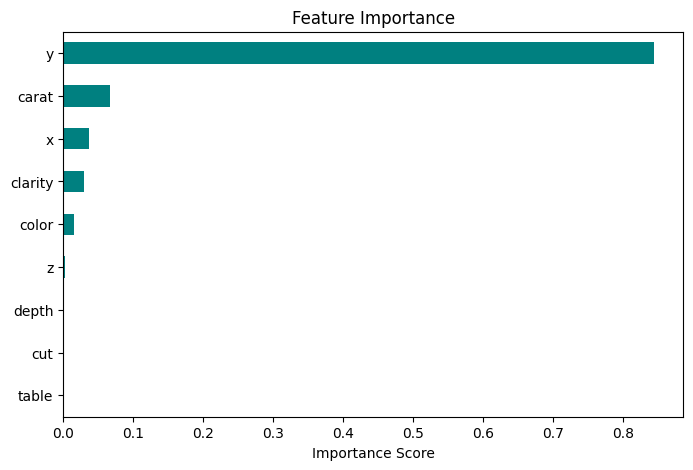

In [10]:
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', color='teal', figsize=(8,5))
plt.title('Feature Importance')
plt.xlabel('Importance Score')
plt.show()

In [11]:
import os
os.makedirs('../backend', exist_ok=True)
joblib.dump(model, '../backend/diamond_model.pkl')
print("Model saved to backend/diamond_model.pkl ✅")

Model saved to backend/diamond_model.pkl ✅
